# Week 9 — IIR Design, Famous Filters, Rate Conversion 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def time_axis(fs, duration):
    T = 1/fs
    t = np.arange(0, duration, T)
    return t

def generate_sine(f, t, A=1, p=0):
    y = A * np.sin(2 * np.pi * f * t + p)
    return y

def spectrum(x, NFFT=-1):
    if NFFT == -1:
        NFFT = len(x)
    X = np.fft.fft(x, NFFT)
    N = len(X)
    X = X[:N//2]
    mag = np.abs(X)*2/N
    freq = np.arange( len(mag) ) * fs / N
    return freq, mag

## Example : Apply IIR filter

In [6]:
# Create IIR filter
# สร้างตัวกรอง IIR ด้วย butter
fs = 100
b, a = signal.butter(2, 20, fs=fs, btype="lowpass")
print("b =", np.round(b, 5))
print("a =", np.round(a, 5))

b = [0.20657 0.41314 0.20657]
a = [ 1.      -0.36953  0.19582]


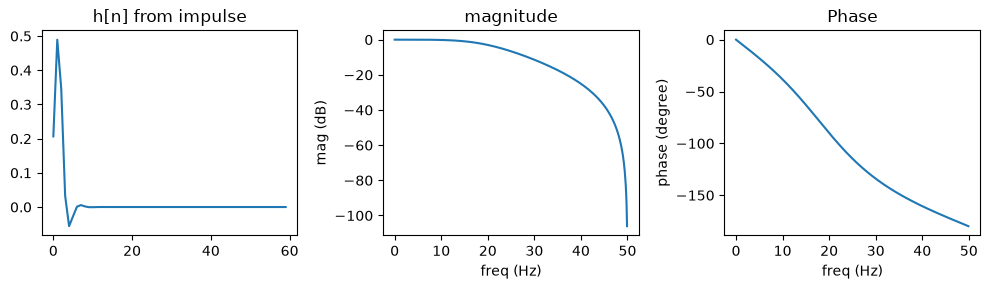

In [9]:
plt.figure( figsize=(10, 3))
# สร้าง impulse เพื่อแสดง impulse response
imp = np.zeros(60); imp[0] = 1
h = signal.lfilter(b, a, imp)
plt.subplot(1,3,1)
plt.plot(h)
plt.title("h[n] from impulse")

# นำ b กับ a ไปคำนวณการตอบสนองทางความถี่ ด้วย freqz เหมือนเดิมทุกอย่าง
w, hh = signal.freqz(b, a, fs=fs)
mag = 20*np.log10( np.abs(hh) )
plt.subplot(1,3,2)
plt.plot(w, mag)
plt.xlabel("freq (Hz)"); plt.ylabel("mag (dB)"); plt.title("magnitude");

phase = np.angle(hh, deg=True)
plt.subplot(1,3,3)
plt.plot(w, phase)
plt.xlabel("freq (Hz)"); plt.ylabel("phase (degree)"); plt.title("Phase")

plt.tight_layout()
plt.show()

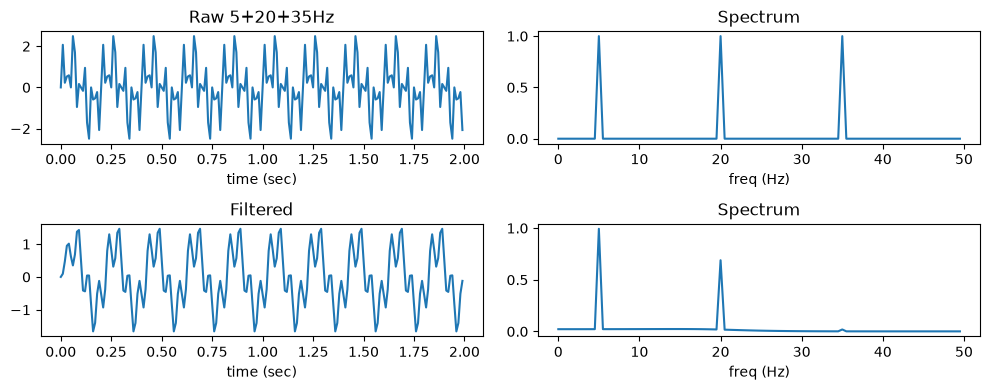

In [12]:
# Apply IIR filter
# สร้างสัญญาณ
fs = 100
t = time_axis(fs, 2.0)
x = generate_sine(5, t) + generate_sine(20, t) + generate_sine(35, t)

# ตัวกรองเดิม butter order 4 ที่ cutoff 20
b, a = signal.butter(4, 20, fs=fs, btype="lowpass")

# ใช้ตัวกรอง ต่างจาก FIR แค่ว่า a ไม่ใช่ [1] แล้ว
y = signal.lfilter(b, a, x)

plt.figure( figsize=(10, 4) )
plt.subplot(2,2,1)
plt.plot(t, x); plt.title("Raw 5+20+35Hz"); plt.xlabel("time (sec)")
freq, mag = spectrum( x )
plt.subplot(2,2,2)
plt.plot(freq, mag); plt.title("Spectrum"); plt.xlabel("freq (Hz)")

plt.subplot(2,2,3)
plt.plot(t, y); plt.title("Filtered"); plt.xlabel("time (sec)")
freq, mag = spectrum( y )
plt.subplot(2,2,4)
plt.plot(freq, mag); plt.title("Spectrum"); plt.xlabel("freq (Hz)")

plt.tight_layout()
plt.show()

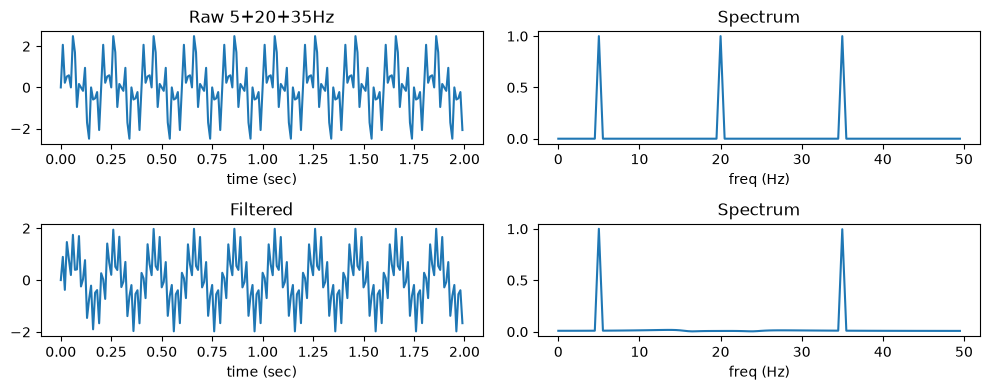

In [5]:
# Apply IIR filter : อีกรูปแบบหนึ่ง
# แบบเดียวกับที่เราทำกับ FIR คือ bandstop 15 ถึง 25
fs = 100
t = time_axis(fs, 2.0)
x = generate_sine(5, t) + generate_sine(20, t) + generate_sine(35, t)

b, a = signal.butter(4, [15, 25], fs=fs, btype="bandstop")
y = signal.lfilter(b, a, x)

plt.figure( figsize=(10, 4) )
plt.subplot(2,2,1)
plt.plot(t, x); plt.title("Raw 5+20+35Hz"); plt.xlabel("time (sec)")
freq, mag = spectrum( x )
plt.subplot(2,2,2)
plt.plot(freq, mag); plt.title("Spectrum"); plt.xlabel("freq (Hz)")

plt.subplot(2,2,3)
plt.plot(t, y); plt.title("Filtered"); plt.xlabel("time (sec)")
freq, mag = spectrum( y )
plt.subplot(2,2,4)
plt.plot(freq, mag); plt.title("Spectrum"); plt.xlabel("freq (Hz)")

plt.tight_layout()
plt.show()

## Exercise 1

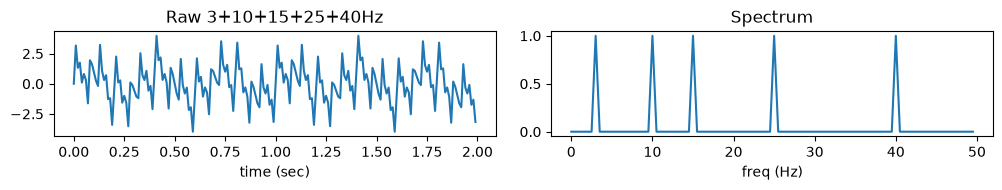

In [13]:
# Ex1: filter a multi frequency signal
# สร้างสัญญาณ sine ความถี่ 3, 10, 15, 25, 40 Hz ที่ fs=100, duration=2
fs = 100
t = time_axis(fs, 2.0)
x = generate_sine(3, t)
for f in [10, 15, 25, 40]:
    x += generate_sine(f, t)

plt.figure( figsize=(10, 2) )
plt.subplot(1,2,1)
plt.plot(t, x); plt.title("Raw 3+10+15+25+40Hz"); plt.xlabel("time (sec)")
freq, mag = spectrum( x )
plt.subplot(1,2,2)
plt.plot(freq, mag); plt.title("Spectrum"); plt.xlabel("freq (Hz)")
plt.tight_layout(); plt.show()

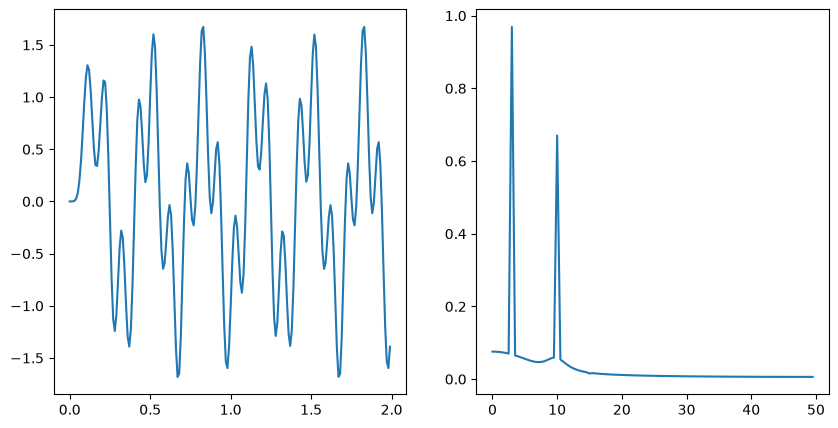

In [36]:
# ออกแบบตัวกรองให้ กรองสัญญาณเหลือ 3, และ 10 Hz
b, a = signal.butter(N=8, Wn=10, fs=fs, btype="lowpass")
y = signal.lfilter(b, a, x)
freq, mag = spectrum(y)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(t, y)
plt.subplot(1, 2, 2)
plt.plot(freq, mag)

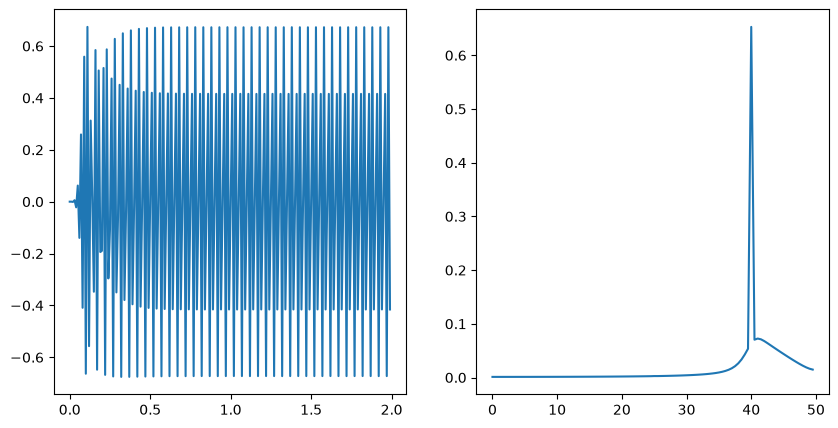

In [37]:
# ออกแบบตัวกรองให้ กรองสัญญาณเหลือ 40 Hz
b, a = signal.butter(N=8, Wn=40, fs=fs, btype="highpass")
y = signal.lfilter(b, a, x)
freq, mag = spectrum(y)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(t, y)
plt.subplot(1, 2, 2)
plt.plot(freq, mag)


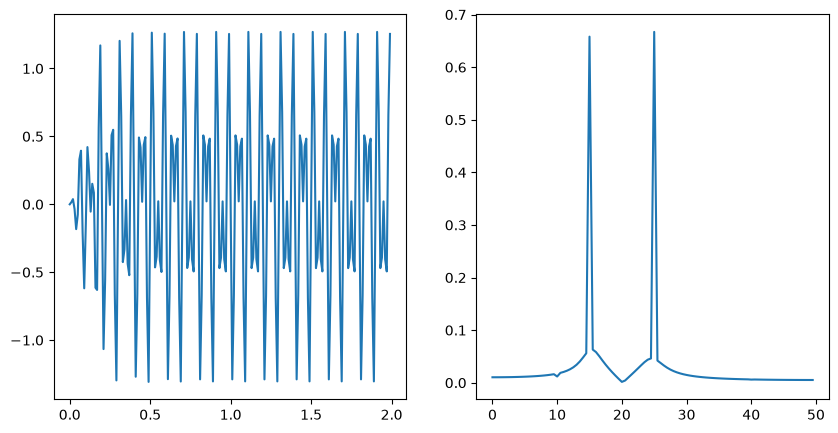

In [38]:
# ออกแบบตัวกรองให้ กรองสัญญาณเหลือ 15, และ 25 Hz
b, a = signal.butter(N=4, Wn=[15, 25], fs=fs, btype="bandpass")
y = signal.lfilter(b, a, x)
freq, mag = spectrum(y)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(t, y)
plt.subplot(1, 2, 2)
plt.plot(freq, mag)

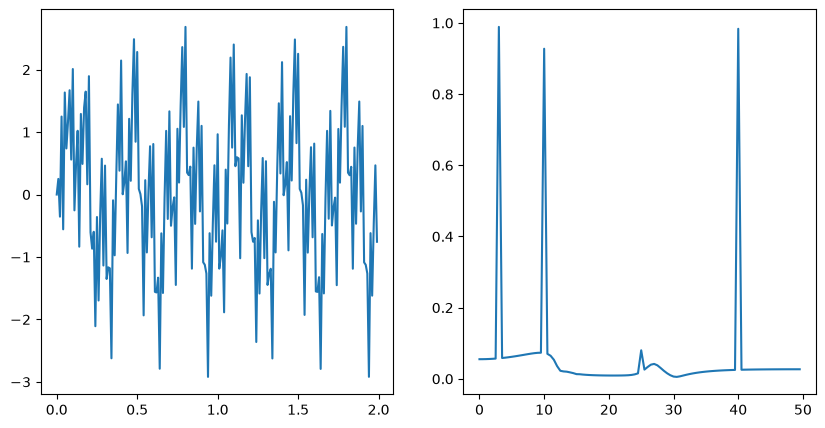

In [43]:
# ออกแบบตัวกรองให้ กรองสัญญาณลบ 15, และ 25 Hz
b, a = signal.butter(N=8, Wn=[12, 27], fs=fs, btype="bandstop")

y = signal.lfilter(b, a, x)
freq, mag = spectrum(y)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(t, y)
plt.subplot(1, 2, 2)
plt.plot(freq, mag)

## Exercise 2 : FIR vs IIR

51 1
11 11


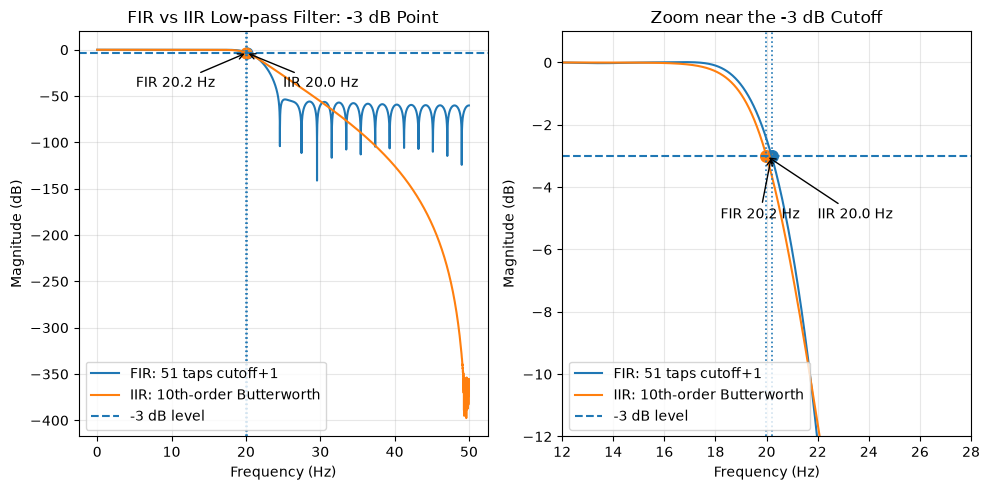

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Example specifications
fs = 100.0
target_fc = 20.0

# FIR: Hamming-window low-pass
numtaps = 51
b_fir = signal.firwin(numtaps=numtaps, cutoff=target_fc+1, fs=fs, window="hamming")
a_fir = [1.0]

# IIR: Butterworth low-pass
order = 10
b_iir, a_iir = signal.butter(N=order, Wn=target_fc, btype="low", fs=fs)
print(len(b_fir), len(a_fir))
print(len(b_iir), len(a_iir))

# Frequency responses
w_fir, h_fir = signal.freqz(b_fir, a_fir, worN=8192, fs=fs)
w_iir, h_iir = signal.freqz(b_iir, a_iir, worN=8192, fs=fs)

mag_fir = 20 * np.log10(np.abs(h_fir))
mag_iir = 20 * np.log10(np.abs(h_iir))

# Find frequency nearest to -3 dB
idx_fir = np.argmin(np.abs(mag_fir + 3))
idx_iir = np.argmin(np.abs(mag_iir + 3))

f3_fir = w_fir[idx_fir]
f3_iir = w_iir[idx_iir]
m3_fir = mag_fir[idx_fir]
m3_iir = mag_iir[idx_iir]

# Plot 1: full response
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.plot(w_fir, mag_fir, label=f"FIR: {numtaps} taps cutoff+1")
plt.plot(w_iir, mag_iir, label=f"IIR: {order}th-order Butterworth")

plt.axhline(-3, linestyle="--", linewidth=1.5, label="-3 dB level")
plt.axvline(f3_fir, linestyle=":", linewidth=1.2)
plt.axvline(f3_iir, linestyle=":", linewidth=1.2)

plt.scatter([f3_fir], [m3_fir], s=60)
plt.scatter([f3_iir], [m3_iir], s=60)

plt.annotate(f"FIR {f3_fir:.1f} Hz",
             xy=(f3_fir, m3_fir),
             xytext=(f3_fir - 15, -40),
             arrowprops=dict(arrowstyle="->"))

plt.annotate(f"IIR {f3_iir:.1f} Hz",
             xy=(f3_iir, m3_iir),
             xytext=(f3_iir + 5, -40),
             arrowprops=dict(arrowstyle="->"))

# plt.xlim(0, 250)
# plt.ylim(-60, 3)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("FIR vs IIR Low-pass Filter: -3 dB Point")
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: zoom near cutoff
plt.subplot(1,2,2)
plt.plot(w_fir, mag_fir, label=f"FIR: {numtaps} taps cutoff+1")
plt.plot(w_iir, mag_iir, label=f"IIR: {order}th-order Butterworth")

plt.axhline(-3, linestyle="--", linewidth=1.5, label="-3 dB level")
plt.axvline(f3_fir, linestyle=":", linewidth=1.2)
plt.axvline(f3_iir, linestyle=":", linewidth=1.2)
plt.scatter([f3_fir], [m3_fir], s=70)
plt.scatter([f3_iir], [m3_iir], s=70)

plt.annotate(f"FIR {f3_fir:.1f} Hz",
             xy=(f3_fir, m3_fir),
             xytext=(f3_fir - 2, -5),
             arrowprops=dict(arrowstyle="->"))

plt.annotate(f"IIR {f3_iir:.1f} Hz",
             xy=(f3_iir, m3_iir),
             xytext=(f3_iir + 2, -5),
             arrowprops=dict(arrowstyle="->"))

plt.xlim(12, 28)
plt.ylim(-12, 1)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Zoom near the -3 dB Cutoff")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [67]:
def plot_spect(x, b_fir, a_fir, b_iir, a_iir, btype):
    plt.figure(figsize=(10, 4))
    plt.subplot(2, 3, 1)
    plt.plot(t, x)
    plt.title("raw 3+10+15+25+40Hz")

    freq, mag = spectrum(x)
    # plt.subplot(2, 3, 2)
    # plt.plot(freq, mag)
    # ออกแบบตัวกรองให้ กรองสัญญาณเหลือ 3, และ 10 Hz
    # using fir
    b = signal.firwin(numtaps = b_fir, cutoff = a_fir, fs = fs, pass_zero = btype)
    a = [1]
    y = signal.lfilter(b, a, x)
    freq, mag = spectrum(y)
    plt.subplot(2, 3, 2)
    plt.title("freq domain")
    plt.plot(freq, mag)
    plt.subplot(2, 3, 3)
    plt.title("FIR")
    plt.plot(t,y)
    #iir
    plt.subplot(2, 3, 4)
    plt.plot(t, x)
    plt.title("raw 3+10+15+25+40Hz")


    b, a = signal.butter(N=b_iir, Wn=a_iir, fs=fs, btype=btype)
    y = signal.lfilter(b, a, x)
    freq, mag = spectrum(y)
    plt.subplot(2, 3, 5)
    plt.title("freq domain")
    plt.plot(freq, mag)
    plt.subplot(2, 3, 6)
    # plt.plot(freq, mag)
    plt.plot(t,y)
    plt.title("IIR")


    plt.tight_layout()

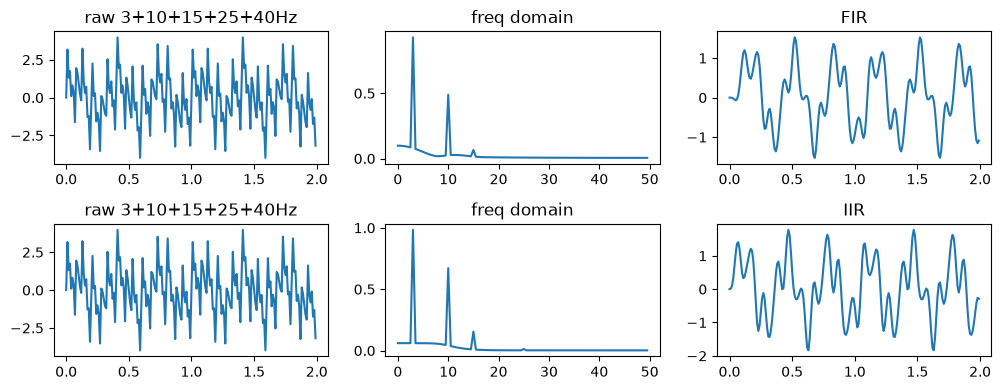

In [77]:
# Exercise2
# จากสัญญาณข้อ 1 ความถี่ 3, 10, 15, 25, 40 Hz ที่ fs=100, duration=2
# สร้างตัวกรอง FIR และ IIR ที่ทำงานตามที่กำหนด และแสดงการเปรียบเทียบ ด้วย subplot 2,3,x
# | raw signal | freq response | filtered signal | -> (FIR)
# | raw signal | freq response | filtered signal | -> (IIR)
# plot สัญญาณต้นฉบับ และสัญญาณที่กรองแล้วใน subplot เดียวกัน

fs = 100; duration = 2; t = time_axis(fs, duration)
x = generate_sine(3, t) + generate_sine(10, t) + generate_sine(15, t) + generate_sine(25, t) + generate_sine(40, t)
plot_spect(x, b_fir = 21, a_fir = 10, b_iir = 4, a_iir = 10, btype = "lowpass")

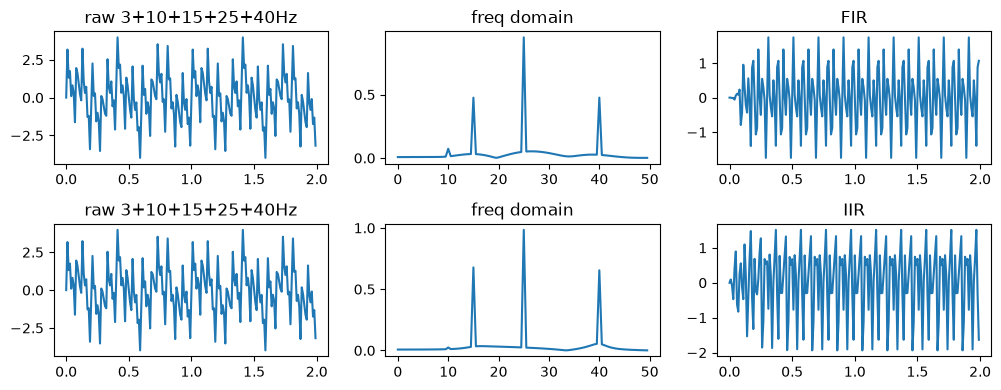

In [76]:
# ออกแบบตัวกรองให้ กรองสัญญาณเหลือ 15, 25 และ 40 Hz
plot_spect(x, 21, [15, 40], 6, [15, 40], btype = "bandpass")

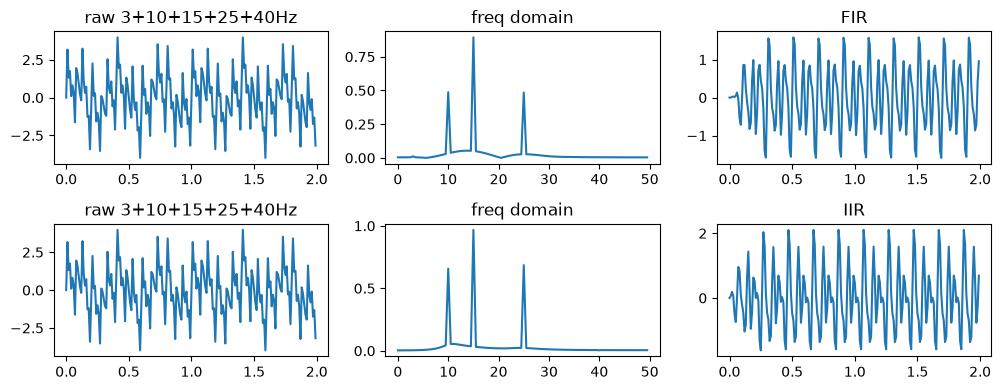

In [80]:
# ออกแบบตัวกรองให้ กรองสัญญาณเหลือ 10, 15, และ 25 Hz
plot_spect(x, 21, [10, 25], 4, [10, 25], btype = "bandpass")

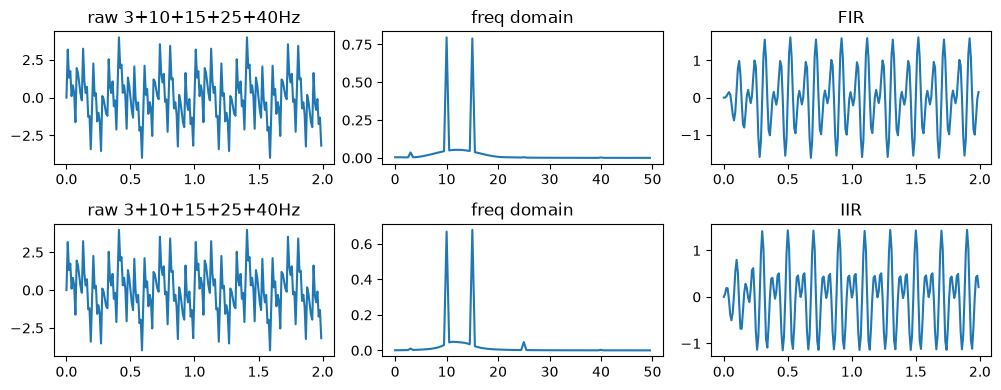

In [83]:
# ออกแบบตัวกรองให้ กรองสัญญาณเหลือ 10 และ 15 Hz
plot_spect(x, 21, [10, 15], 2, [10, 15], btype = "bandpass")

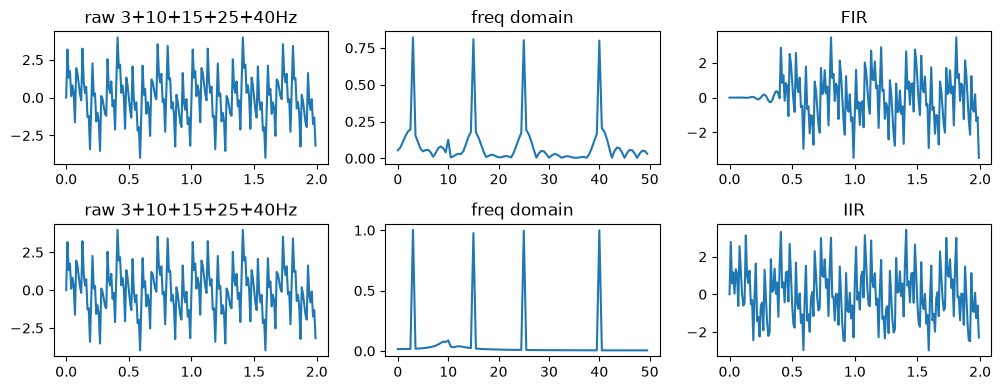

In [98]:
plot_spect(x, 81, [9, 12], 2, [9, 12], btype = "bandstop")


## Exercise 3 : Famous FIR

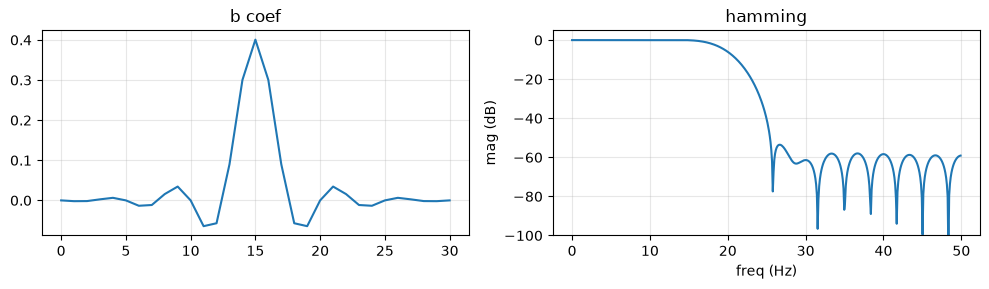

In [99]:
# window คนละแบบ ที่ numtaps เท่ากัน ให้ผลต่างกันอย่างไร
# จงเปลี่ยน window แล้วดูว่า ขอบชันขึ้นหรือลง และ side lobe ลึกขึ้นหรือตื้นขึ้น
fs = 100
name = "hamming"
b = signal.firwin(31, 20, fs=fs, window=name)
w, h = signal.freqz(b, [1.0], fs=fs)

plt.figure( figsize=(10, 3) )
plt.subplot(1, 2, 1)
plt.plot(b); plt.title("b coef"); plt.grid(alpha=.3)
plt.subplot(1, 2, 2)
plt.plot(w, 20*np.log10(np.abs(h)))
plt.ylim(-100, 5); plt.grid(alpha=.3)
plt.xlabel("freq (Hz)"); plt.ylabel("mag (dB)"); plt.title("hamming")
plt.tight_layout()
plt.show()

In [28]:
# แบบฝึกหัด 3 : ลองเปลี่ยนเป็น boxcar, hann, blackman และ flattop
# แล้วตอบว่า window ใดขอบชันที่สุด และ window ใด side lobe ลึกที่สุด
# b = signal.firwin(31, 20, fs=fs, window="??")


## Exercise 4 : Famous IIR

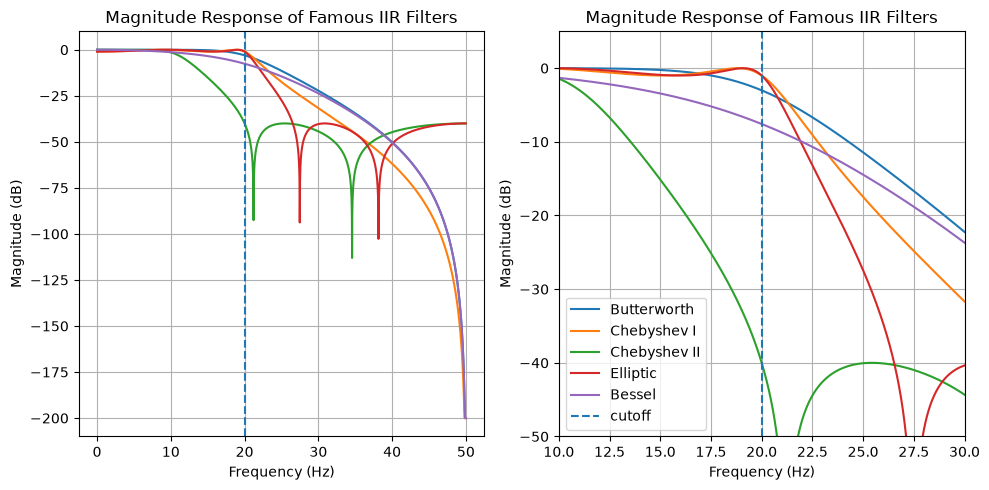

In [100]:
fs = 100
fc = 20
N = 4

filters = {}
filters["Butterworth"] = signal.butter( N, fc, btype="lowpass", fs=fs )
filters["Chebyshev I"] = signal.cheby1( N, rp=1, Wn=fc, btype="lowpass", fs=fs)
filters["Chebyshev II"] = signal.cheby2( N, rs=40, Wn=fc, btype="lowpass", fs=fs)
filters["Elliptic"] = signal.ellip( N, rp=1, rs=40, Wn=fc, btype="lowpass", fs=fs)
filters["Bessel"] = signal.bessel( N, fc, btype="lowpass", fs=fs, norm="phase")

plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
for name, (b, a) in filters.items():
    f, H = signal.freqz(b, a, worN=4096, fs=fs)
    mag = 20 * np.log10(np.maximum(np.abs(H), 1e-10))
    plt.plot(f, mag, label=name)

plt.axvline(fc, linestyle="--", label="cutoff")
plt.title("Magnitude Response of Famous IIR Filters")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid()

plt.subplot(1,2,2)
for name, (b, a) in filters.items():
    f, H = signal.freqz(b, a, worN=4096, fs=fs)
    mag = 20 * np.log10(np.maximum(np.abs(H), 1e-10))
    plt.plot(f, mag, label=name)

plt.axvline(fc, linestyle="--", label="cutoff")
plt.title("Magnitude Response of Famous IIR Filters")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")

plt.xlim(10, 30)
plt.ylim(-50, 5)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def plot_iir(x, ):
    plt.figure( figsize=(10, 4) )
    plt.subplot(2,2,1)
    plt.plot(t, x); plt.title("Raw 3+10+15+25+40Hz"); plt.xlabel("time (sec)")
    freq, mag = spectrum( x )
    plt.subplot(2,2,2)
    plt.plot(freq, mag); plt.title("Spectrum"); plt.xlabel("freq (Hz)")
    plt.subplot(2,2,3)
    plt.plot(t, y); plt.title("butter"); plt.xlabel("time (sec)")
    freq, mag = spectrum( y )
    plt.subplot(2,2,4)
    plt.plot(freq, mag); plt.title("Spectrum"); plt.xlabel("freq (Hz)")
    plt.tight_layout()
    plt.show()

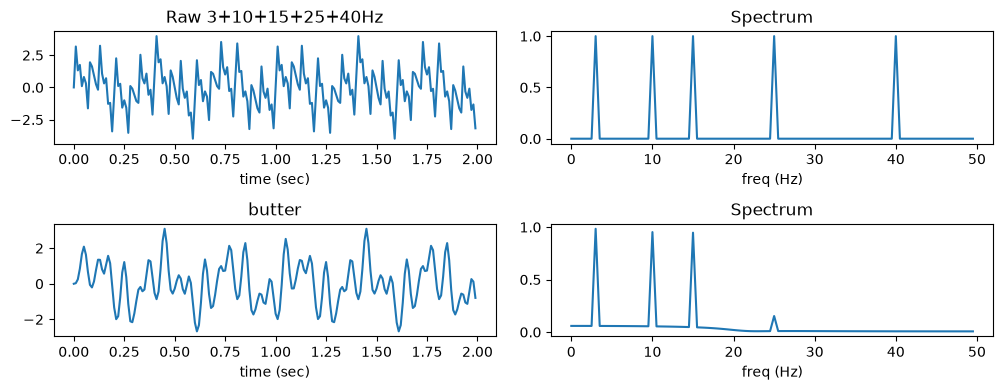

In [101]:
# สัญญาณผสมตัวเดิมจาก Exercise 1
fs = 100
t = time_axis(fs, 2.0)
x = generate_sine(3, t)
for f in [10, 15, 25, 40]:
    x += generate_sine(f, t)

# ตระกูลแรก Butterworth ที่ order 6 cutoff 20
b, a = signal.butter(6, 20, fs=fs)
y = signal.lfilter(b, a, x)

plt.figure( figsize=(10, 4) )
plt.subplot(2,2,1)
plt.plot(t, x); plt.title("Raw 3+10+15+25+40Hz"); plt.xlabel("time (sec)")
freq, mag = spectrum( x )
plt.subplot(2,2,2)
plt.plot(freq, mag); plt.title("Spectrum"); plt.xlabel("freq (Hz)")
plt.subplot(2,2,3)
plt.plot(t, y); plt.title("butter"); plt.xlabel("time (sec)")
freq, mag = spectrum( y )
plt.subplot(2,2,4)
plt.plot(freq, mag); plt.title("Spectrum"); plt.xlabel("freq (Hz)")
plt.tight_layout()
plt.show()

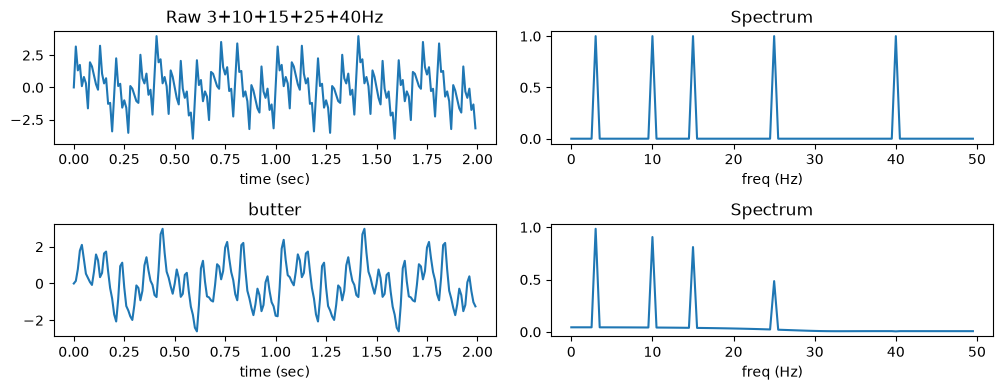

In [102]:
# แบบฝึกหัด 4 : ทำแบบเดียวกันกับอีกสี่ตระกูล ที่ order 6 cutoff 20 เท่ากัน
# แล้วตอบว่า ตระกูลใดเก็บ 15 Hz ไว้ได้มากที่สุด และตระกูลใดน้อยที่สุด
# b, a = signal.cheby1(6, 1, 20, fs=fs)
# b, a = signal.cheby2(6, 40, 20, fs=fs)
# b, a = signal.ellip(6, 1, 40, 20, fs=fs)
# b, a = signal.bessel(6, 20, fs=fs, norm="mag")
b, a = signal.bessel(6, 20, fs=fs, norm="mag")
y = signal.lfilter(b, a, x)
plt.figure( figsize=(10, 4) )
plt.subplot(2,2,1)
plt.plot(t, x); plt.title("Raw 3+10+15+25+40Hz"); plt.xlabel("time (sec)")
freq, mag = spectrum( x )
plt.subplot(2,2,2)
plt.plot(freq, mag); plt.title("Spectrum"); plt.xlabel("freq (Hz)")
plt.subplot(2,2,3)
plt.plot(t, y); plt.title("butter"); plt.xlabel("time (sec)")
freq, mag = spectrum( y )
plt.subplot(2,2,4)
plt.plot(freq, mag); plt.title("Spectrum"); plt.xlabel("freq (Hz)")
plt.tight_layout()
plt.show()

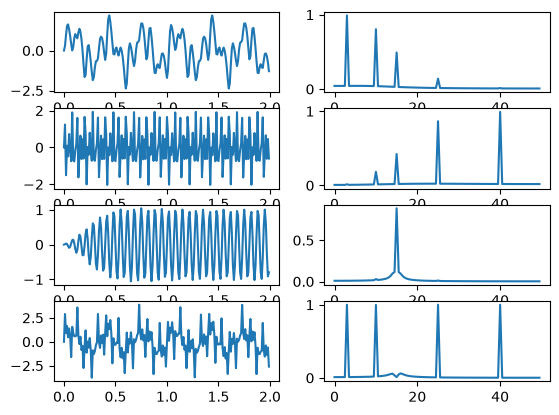

In [108]:
fs = 100
t = time_axis(fs, 2.0)
x = generate_sine(3, t)
for f in [10, 15, 25, 40]:
    x += generate_sine(f, t)
# 3 + 10
b, a = signal.butter(N = 2, Wn = 12, fs = fs, btype= "lowpass")
y = signal.lfilter(b, a, x)
plt.subplot(4, 2, 1)
plt.plot(t, y)

freq, mag = spectrum(y)
plt.subplot(4, 2, 2)
plt.plot(freq, mag)
# 25 + 40
b, a = signal.butter(N = 2, Wn = 20, fs = fs, btype= "highpass")
y = signal.lfilter(b, a, x)
plt.subplot(4, 2, 3)
plt.plot(t, y)

freq, mag = spectrum(y)
plt.subplot(4, 2, 4)
plt.plot(freq, mag)

# 15
b, a = signal.butter(N = 2, Wn = [14, 16], fs = fs, btype= "bandpass")
y = signal.lfilter(b, a, x)
plt.subplot(4, 2, 5)
plt.plot(t, y)

freq, mag = spectrum(y)
plt.subplot(4, 2, 6)
plt.plot(freq, mag)

# -15
b, a = signal.butter(N = 2, Wn = [14, 16], fs = fs, btype= "bandstop")
y = signal.lfilter(b, a, x)
plt.subplot(4, 2, 7)
plt.plot(t, y)

freq, mag = spectrum(y)
plt.subplot(4, 2, 8)
plt.plot(freq, mag)

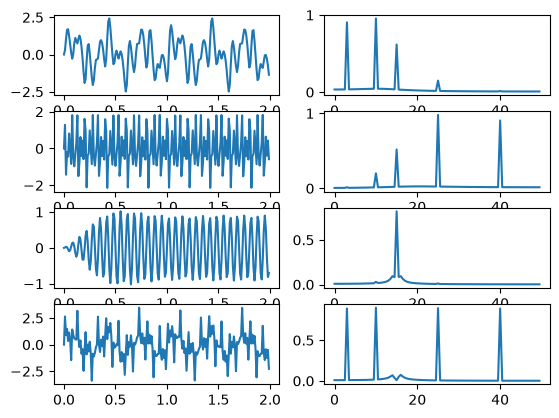

In [112]:
b, a = signal.cheby1(2, rp=1, Wn = 12, btype= "lowpass", fs = fs)
y = signal.lfilter(b, a, x)
plt.subplot(4, 2, 1)
plt.plot(t, y)

freq, mag = spectrum(y)
plt.subplot(4, 2, 2)
plt.plot(freq, mag)
# 25 + 40
b, a = signal.cheby1(2, rp=1, Wn = 20, btype= "highpass", fs = fs)
y = signal.lfilter(b, a, x)
plt.subplot(4, 2, 3)
plt.plot(t, y)

freq, mag = spectrum(y)
plt.subplot(4, 2, 4)
plt.plot(freq, mag)

# 15
b, a = signal.cheby1(2, rp=1, Wn = [14, 16], btype= "bandpass", fs = fs)
y = signal.lfilter(b, a, x)
plt.subplot(4, 2, 5)
plt.plot(t, y)

freq, mag = spectrum(y)
plt.subplot(4, 2, 6)
plt.plot(freq, mag)

# -15
b, a = signal.cheby1(2, rp=1, Wn = [14, 16], btype= "bandstop", fs = fs)
y = signal.lfilter(b, a, x)
plt.subplot(4, 2, 7)
plt.plot(t, y)

freq, mag = spectrum(y)
plt.subplot(4, 2, 8)
plt.plot(freq, mag)

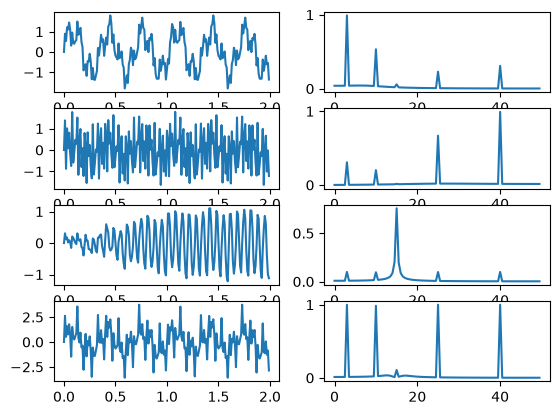

In [122]:
b, a = signal.cheby2(2, rs=10, Wn = 12, btype= "lowpass", fs = fs)
y = signal.lfilter(b, a, x)
plt.subplot(4, 2, 1)
plt.plot(t, y)

freq, mag = spectrum(y)
plt.subplot(4, 2, 2)
plt.plot(freq, mag)
# 25 + 40
b, a = signal.cheby2(2, rs=10, Wn = 20, btype= "highpass", fs = fs)
y = signal.lfilter(b, a, x)
plt.subplot(4, 2, 3)
plt.plot(t, y)

freq, mag = spectrum(y)
plt.subplot(4, 2, 4)
plt.plot(freq, mag)

# 15
b, a = signal.cheby2(2, rs=20, Wn = [14, 16], btype= "bandpass", fs = fs)
y = signal.lfilter(b, a, x)
plt.subplot(4, 2, 5)
plt.plot(t, y)

freq, mag = spectrum(y)
plt.subplot(4, 2, 6)
plt.plot(freq, mag)

# -15
b, a = signal.cheby2(2, rs=20, Wn = [14, 16], btype= "bandstop", fs = fs)
y = signal.lfilter(b, a, x)
plt.subplot(4, 2, 7)
plt.plot(t, y)

freq, mag = spectrum(y)
plt.subplot(4, 2, 8)
plt.plot(freq, mag)

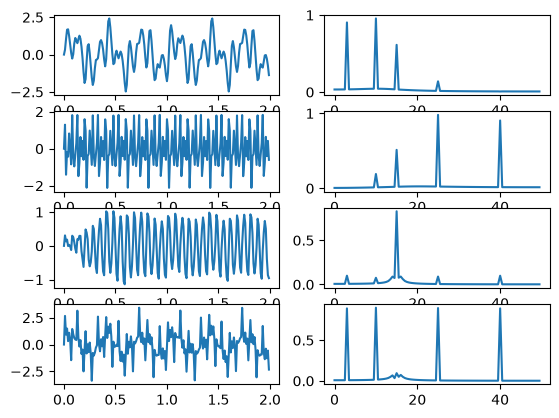

In [118]:
b, a = signal.ellip(2, rp = 1, rs=40, Wn = 12, btype= "lowpass", fs = fs)
y = signal.lfilter(b, a, x)
plt.subplot(4, 2, 1)
plt.plot(t, y)

freq, mag = spectrum(y)
plt.subplot(4, 2, 2)
plt.plot(freq, mag)
# 25 + 40
b, a = signal.ellip(2, rp = 1,  rs=40, Wn = 20, btype= "highpass", fs = fs)
y = signal.lfilter(b, a, x)
plt.subplot(4, 2, 3)
plt.plot(t, y)

freq, mag = spectrum(y)
plt.subplot(4, 2, 4)
plt.plot(freq, mag)

# 15
b, a = signal.ellip(2, rp = 1,  rs=20, Wn = [14, 16], btype= "bandpass", fs = fs)
y = signal.lfilter(b, a, x)
plt.subplot(4, 2, 5)
plt.plot(t, y)

freq, mag = spectrum(y)
plt.subplot(4, 2, 6)
plt.plot(freq, mag)

# -15
b, a = signal.ellip(2, rp = 1, rs=20, Wn = [14, 16], btype= "bandstop", fs = fs)
y = signal.lfilter(b, a, x)
plt.subplot(4, 2, 7)
plt.plot(t, y)

freq, mag = spectrum(y)
plt.subplot(4, 2, 8)
plt.plot(freq, mag)

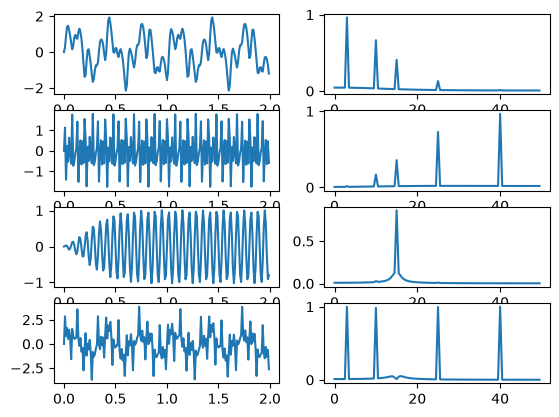

In [119]:
b, a = signal.bessel(2, 12, btype= "lowpass", fs = fs, norm = "phase")
y = signal.lfilter(b, a, x)
plt.subplot(4, 2, 1)
plt.plot(t, y)

freq, mag = spectrum(y)
plt.subplot(4, 2, 2)
plt.plot(freq, mag)
# 25 + 40
b, a = signal.bessel(2, 20, btype= "highpass", fs = fs, norm = "phase")
y = signal.lfilter(b, a, x)
plt.subplot(4, 2, 3)
plt.plot(t, y)

freq, mag = spectrum(y)
plt.subplot(4, 2, 4)
plt.plot(freq, mag)

# 15
b, a = signal.bessel(2, [14, 16], btype= "bandpass", fs = fs, norm = "phase")
y = signal.lfilter(b, a, x)
plt.subplot(4, 2, 5)
plt.plot(t, y)

freq, mag = spectrum(y)
plt.subplot(4, 2, 6)
plt.plot(freq, mag)

# -15
b, a = signal.bessel(2, [14, 16], btype= "bandstop", fs = fs, norm = "phase")
y = signal.lfilter(b, a, x)
plt.subplot(4, 2, 7)
plt.plot(t, y)

freq, mag = spectrum(y)
plt.subplot(4, 2, 8)
plt.plot(freq, mag)